# Trench pull as a GPE dipole — a short demo

This notebook loads one finite-strain, plane-strain flexure model and reproduces the two headline results
of the trench-pull study, interactively:

1. **The force-balance identity** $\Delta N_D = \Delta\mathrm{GPE}^{*}$ — the horizontal driving force equals
   the deficit in the depth-integrated vertical normal stress.
2. **The "corrected density" dipole** — every column carries the same integrated mass, so the trench pull is
   a dipole of the corrected-density *difference* between the trench column and an isostatic reference.

**Model:** a massless total-Lagrangian plate, $h=60$ km, Tresca $\sigma_Y=150$ MPa, applied trench shear
$V=4$ TN/m (the locked baseline `tresca_deep_150_60km_V4`). The analysis lives in `gpe_analysis.py`; the
production figures are made by the `render_*.py` scripts; the models are regenerated by `sandbox_M4.jl`.

## 1. Load the model

In [1]:
import os, sys
# resolve relative paths whether the notebook is launched from the repo root or from finite_strain/
if os.path.basename(os.getcwd()) != "finite_strain" and os.path.isdir("finite_strain"):
    os.chdir("finite_strain")
sys.path.insert(0, ".")
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from gpe_analysis import (Model, reference_lines, trench_ref_km,
                          deformed_shear_gradient, trench_pull)

BASE = "out/paper/set1_rheology/tresca_deep_150_60km_V4"
m = Model(BASE)
print("mesh: Nx =", m.Nx, " Nz =", m.Nz, " plate thickness H =", m.H/1e3, "km")
print("fields:", [n for n in m.names() if "[" in n][:6], "...")

mesh: Nx = 801  Nz = 49  plate thickness H = 60.0 km
fields: ['sigma_xx [Pa]', 'sigma_zz [Pa]', 'sigma_xz [Pa]', 'sigma_xz_cauchy [Pa]', 'dsxz_dx [Pa/m]', 'dszz_dz [Pa/m]'] ...


## 2. Flexural topography

`m.topography()` returns the surface deflection (positive **down**) at each column. The named reference
lines — the trench, the moment maximum, the first isostatic column (deflection zero-crossing), and the outer
rise — come from `reference_lines(m)`.

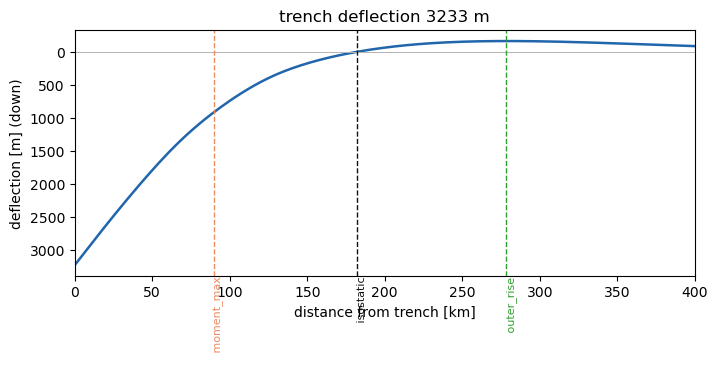

In [2]:
xt  = trench_ref_km(m)
rl  = reference_lines(m)
w   = m.topography()          # deflection [m], positive down
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(m.xkm, w, color="#2166ac", lw=1.8)
ax.axhline(0, color="0.7", lw=0.7)
for key, c in [("moment_max", "#ef8a62"), ("isostatic", "#111"), ("outer_rise", "#2ca02c")]:
    ax.axvline(rl[key], color=c, lw=1.0, ls="--")
    ax.text(rl[key], ax.get_ylim()[1], f" {key}", fontsize=8, color=c, va="top", rotation=90)
ax.invert_yaxis()                                  # down is down
ax.set_xlim(0, 400); ax.set_xlabel("distance from trench [km]"); ax.set_ylabel("deflection [m] (down)")
ax.set_title(f"trench deflection {w[np.argmin(np.abs(m.xkm-xt))]:.0f} m")
plt.show()

## 3. The identity $\Delta N_D = \Delta\mathrm{GPE}^{*}$

`trench_pull(m)` returns the trench pull two ways: as $\Delta\mathrm{GPE}^{*}=-\Delta\bar\sigma_{zz}$ (the
vertical-normal-stress deficit) and as $\Delta N_D=\Delta\!\int(\sigma_{xx}-\sigma_{zz})\,dz$. They agree to
a small fraction of a percent — that is the exact force balance. Below we also trace both across the plate to
show they overlay everywhere, not just at the trench.

ΔGPE*  =  2.542 TN/m
ΔN_D   =  2.543 TN/m   (isostatic reference at x = 182 km)
mismatch = 0.019 %


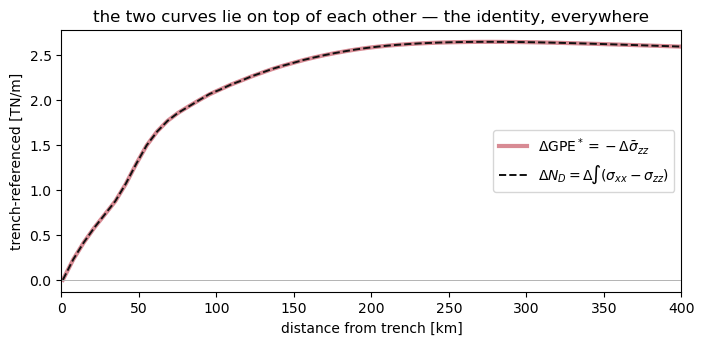

In [3]:
dGPE, dNd, xiso = trench_pull(m)
print(f"ΔGPE*  = {dGPE/1e12:6.3f} TN/m")
print(f"ΔN_D   = {dNd /1e12:6.3f} TN/m   (isostatic reference at x = {xiso:.0f} km)")
print(f"mismatch = {abs(dGPE-dNd)/abs(dGPE)*100:.3f} %")

# trace both across the flexed region, trench-referenced, on the deformed columns
xs = np.linspace(xt, 400, 60)
SzzT, NdT = m.deformed_resultants(xt)
dNd_x, dG_x = [], []
for x in xs:
    Szz, Nd = m.deformed_resultants(x)
    dNd_x.append((Nd - NdT) / 1e12)
    dG_x.append(-(Szz - SzzT) / 1e12)

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(xs, dG_x, color="#b2182b", lw=3.0, alpha=0.5, label=r"$\Delta$GPE$^*=-\Delta\bar\sigma_{zz}$")
ax.plot(xs, dNd_x, color="#111", lw=1.4, ls="--", label=r"$\Delta N_D=\Delta\!\int(\sigma_{xx}-\sigma_{zz})$")
ax.axhline(0, color="0.7", lw=0.7); ax.set_xlim(0, 400)
ax.set_xlabel("distance from trench [km]"); ax.set_ylabel("trench-referenced [TN/m]")
ax.set_title("the two curves lie on top of each other — the identity, everywhere")
ax.legend(); plt.show()

## 4. The corrected-density dipole

The **corrected density** is the true density plus a *pseudo* density that stands in for the horizontal
gradient of the shear support:
$$\hat\rho_c = \rho + g^{-1}\,\partial_x\sigma_{xz}.$$
Two facts make the trench pull a clean dipole:

- every column integrates to the **same** corrected mass (isostasy), and
- the difference between the trench and an isostatic column is therefore a pure dipole whose moment is
  $\Delta\mathrm{GPE}^{*}$.

We build $\hat\rho_c(z)$ at three columns and plot it (panel A), then show the cumulative average converging
to one value (panel B).

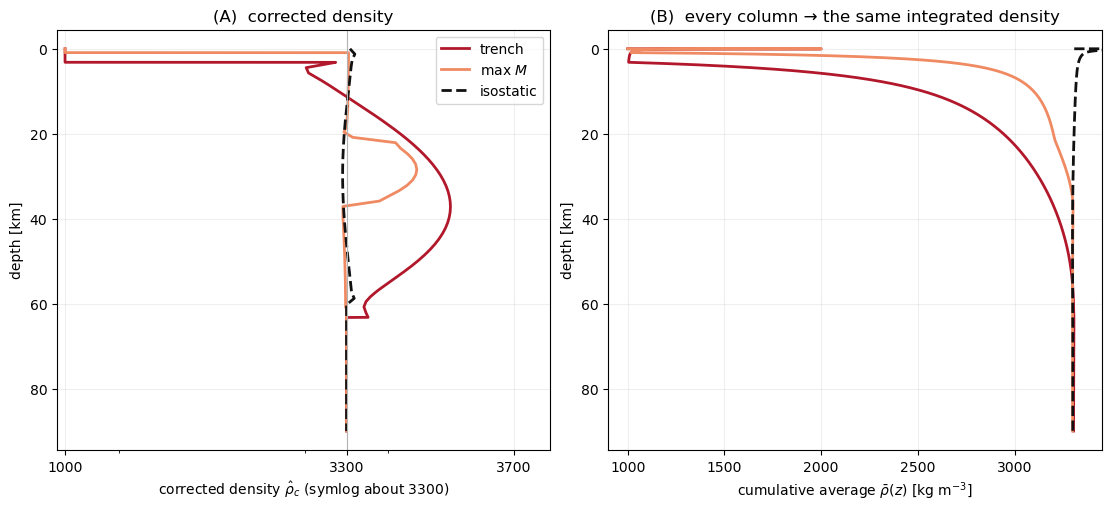

In [4]:
from matplotlib.ticker import FixedLocator, FixedFormatter
G, RW, RP = 9.81, 1000.0, 3300.0
xmm, xi = rl["moment_max"], rl["isostatic"]
COLS = [("trench", xt, "#b2182b"), ("max $M$", xmm, "#ef8a62"), ("isostatic", xi, "#111")]
ZG = np.linspace(0, 90e3, 6000); DZ = ZG[1] - ZG[0]

def corrected(xk):
    L, tau = deformed_shear_gradient(m, xk); z = L["z"]; top, base = z[0], z[-1]
    r = np.full_like(ZG, RP); r[ZG < top] = RW                       # water above the deflected top
    ip = (ZG >= top) & (ZG <= base); r[ip] = RP + np.interp(ZG[ip], z, tau / G)  # plate: 3300 + pseudo
    return r

rc = {lab: corrected(xk) for lab, xk, _ in COLS}
fig, ax = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
for lab, xk, c in COLS:
    ax[0].plot(rc[lab] - RP, ZG/1e3, color=c, lw=2.0, ls=("--" if lab == "isostatic" else "-"), label=lab)
ax[0].set_xscale("symlog", linthresh=400.0)
ticks = [-2300, 0, 400]; ax[0].xaxis.set_major_locator(FixedLocator(ticks))
ax[0].xaxis.set_major_formatter(FixedFormatter([f"{RP+t:.0f}" for t in ticks]))
ax[0].axvline(0, color="0.7", lw=0.8); ax[0].invert_yaxis(); ax[0].set_xlim(-2600, 700)
ax[0].set_xlabel(r"corrected density $\hat\rho_c$ (symlog about 3300)"); ax[0].set_ylabel("depth [km]")
ax[0].set_title("(A)  corrected density"); ax[0].legend(); ax[0].grid(alpha=0.2)

for lab, xk, c in COLS:
    avg = np.cumsum(rc[lab]) * DZ / np.maximum(ZG, DZ)
    ax[1].plot(avg, ZG/1e3, color=c, lw=2.0, ls=("--" if lab == "isostatic" else "-"), label=lab)
ax[1].invert_yaxis(); ax[1].set_xlim(900, 3450)
ax[1].set_xlabel(r"cumulative average $\bar\rho(z)$ [kg m$^{-3}$]"); ax[1].set_ylabel("depth [km]")
ax[1].set_title("(B)  every column → the same integrated density"); ax[1].grid(alpha=0.2)
plt.show()

### The dipole, split a priori

The corrected-density *difference* (trench − isostatic) splits into a shallow **true** lobe (the water deficit
over the deflected depth $w$, centred at $w/2$) and a deep **pseudo** lobe (the shear support). Their moment
reproduces $\Delta\mathrm{GPE}^{*}$.

In [5]:
def dipole_lobes(xk):
    L, tau = deformed_shear_gradient(m, xk); z = L["z"]; w = z[0]
    m_true = (RP - RW) * w; z_true = w / 2.0                          # water deficit — known from the deflected depth
    m_ps = np.trapz(tau, z) / G                                       # shear support — from the FE gradient
    z_ps = np.trapz(z * tau, z) / np.trapz(tau, z)
    return dict(m_true=m_true, z_true=z_true, m_ps=m_ps, z_ps=z_ps)

d = dipole_lobes(xt)
arm = (d["z_ps"] - d["z_true"]) / 1e3
gmL = G * 0.5 * (abs(d["m_true"]) + abs(d["m_ps"])) * (d["z_ps"] - d["z_true"]) / 1e12
print(f"true (water) lobe : mass {abs(d['m_true']):.2e} kg/m²  at {d['z_true']/1e3:5.2f} km")
print(f"pseudo (shear)    : mass {abs(d['m_ps']):.2e} kg/m²  at {d['z_ps']/1e3:5.2f} km")
print(f"dipole arm ≈ {arm:.0f} km,  g·m·arm ≈ {gmL:.2f} TN/m  (vs measured pull {dGPE/1e12:.2f} TN/m)")

true (water) lobe : mass 7.32e+06 kg/m²  at  1.59 km
pseudo (shear)    : mass 7.72e+06 kg/m²  at 38.80 km
dipole arm ≈ 37 km,  g·m·arm ≈ 2.75 TN/m  (vs measured pull 2.54 TN/m)


## Where to go next

- **Full figure set:** the `render_*.py` scripts rebuild every manuscript figure (`render_hero.py`,
  `render_gpe_correlation.py`, `render_profiles.py`, …). The multi-suite figures need the full `out/paper/`
  study, not just the committed Suite-1 subset.
- **Regenerate the models:** `julia sandbox_M4.jl regen135` (rheology suite), `... vsweep`, etc.
- **The corrected-density figure** is `render_corrected_density.py` (still exploratory).
- **The N_D vs N_x gauge story** (why the absolute $N_D$ level is a free far-field choice while
  $\Delta N_D=\Delta\mathrm{GPE}^{*}$ is fixed) is explored with the `set2_nd_sweep` membrane runs.